<a href="https://colab.research.google.com/github/farformbath/UAS_Alpro/blob/main/Analisis_Diabetes_DecissionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
nama_kolom = ['Kehamilan', 'Glukosa', 'TekananDarah', 'KetebalanKulit', 'Insulin', 'BMI', 'RiwayatKeluarga', 'Usia','Hasil']
data  = pd.read_csv(url, names=nama_kolom)
data.head()
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Kehamilan        768 non-null    int64  
 1   Glukosa          768 non-null    int64  
 2   TekananDarah     768 non-null    int64  
 3   KetebalanKulit   768 non-null    int64  
 4   Insulin          768 non-null    int64  
 5   BMI              768 non-null    float64
 6   RiwayatKeluarga  768 non-null    float64
 7   Usia             768 non-null    int64  
 8   Hasil            768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Kehamilan,Glukosa,TekananDarah,KetebalanKulit,Insulin,BMI,RiwayatKeluarga,Usia,Hasil
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
from sklearn.model_selection import train_test_split
# berisi kode untuk membagi data training dan testing, 80% training, 20% testing.

# memisahkan fitur x dan target y
X = data.drop('Hasil', axis=1)
y = data['Hasil']

# membagi data training 80% dan testing 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('data training siap', X_train.shape)
print('data testing siap', X_test.shape)

data training siap (614, 8)
data testing siap (154, 8)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model_ClassifierDiabet = DecisionTreeClassifier(max_depth=5, random_state=42)
model_ClassifierDiabet.fit(X_train, y_train)
print('model sudah dilatih')

model sudah dilatih


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

prediksi = model_ClassifierDiabet.predict(X_test)

skor_akurasi = accuracy_score(y_test, prediksi)
print(f"Akurasi Model ClassifierDiabet: {skor_akurasi * 100:.2f}%")
print("\nLaporan Lengkap:\n", classification_report(y_test, prediksi))

Akurasi Model ClassifierDiabet: 79.22%

Laporan Lengkap:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84        99
           1       0.74      0.64      0.69        55

    accuracy                           0.79       154
   macro avg       0.78      0.76      0.77       154
weighted avg       0.79      0.79      0.79       154



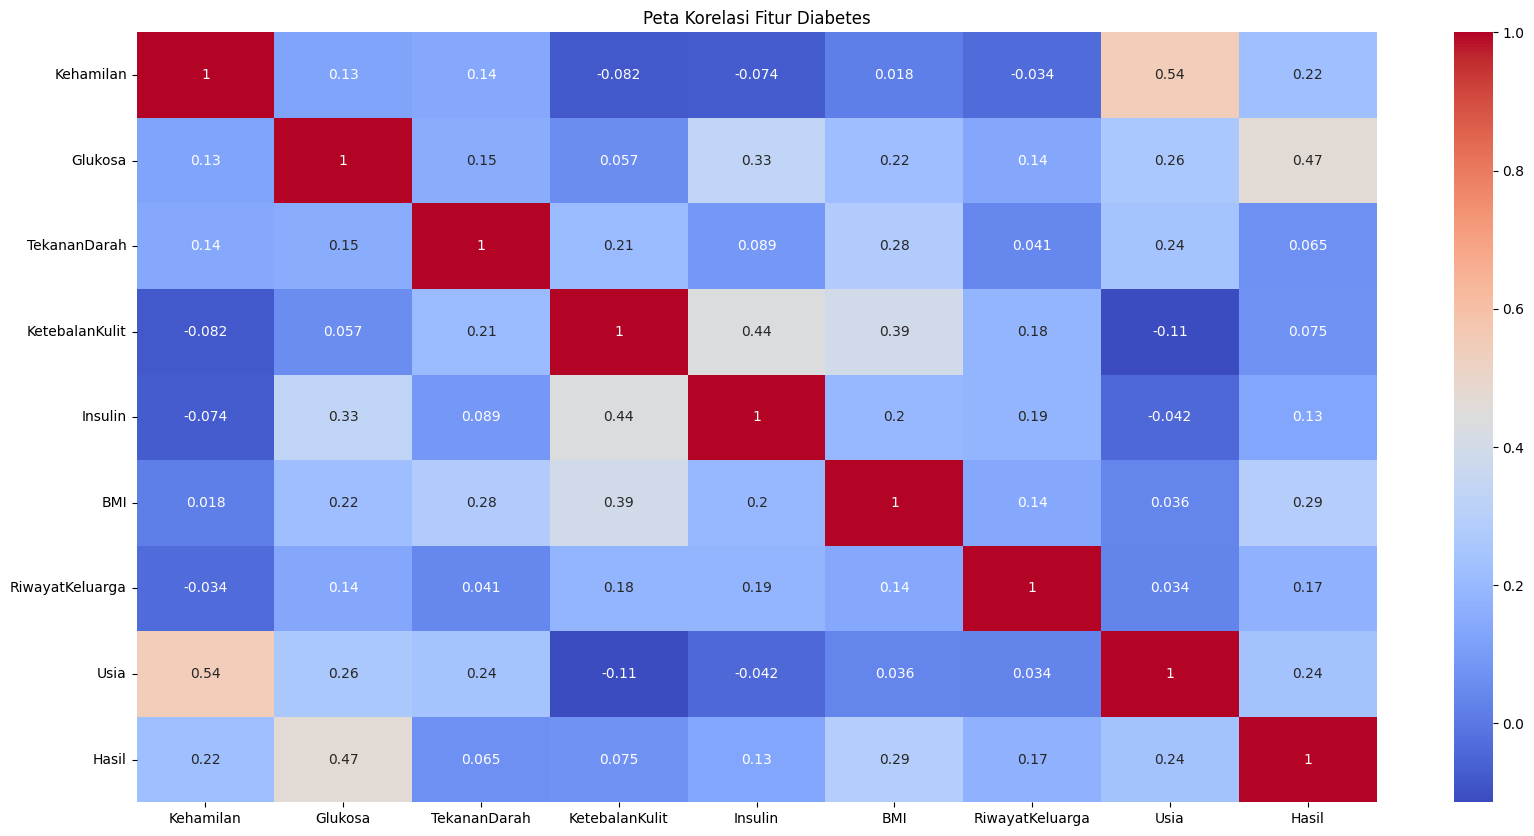

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Peta Korelasi Fitur Diabetes")
plt.show()

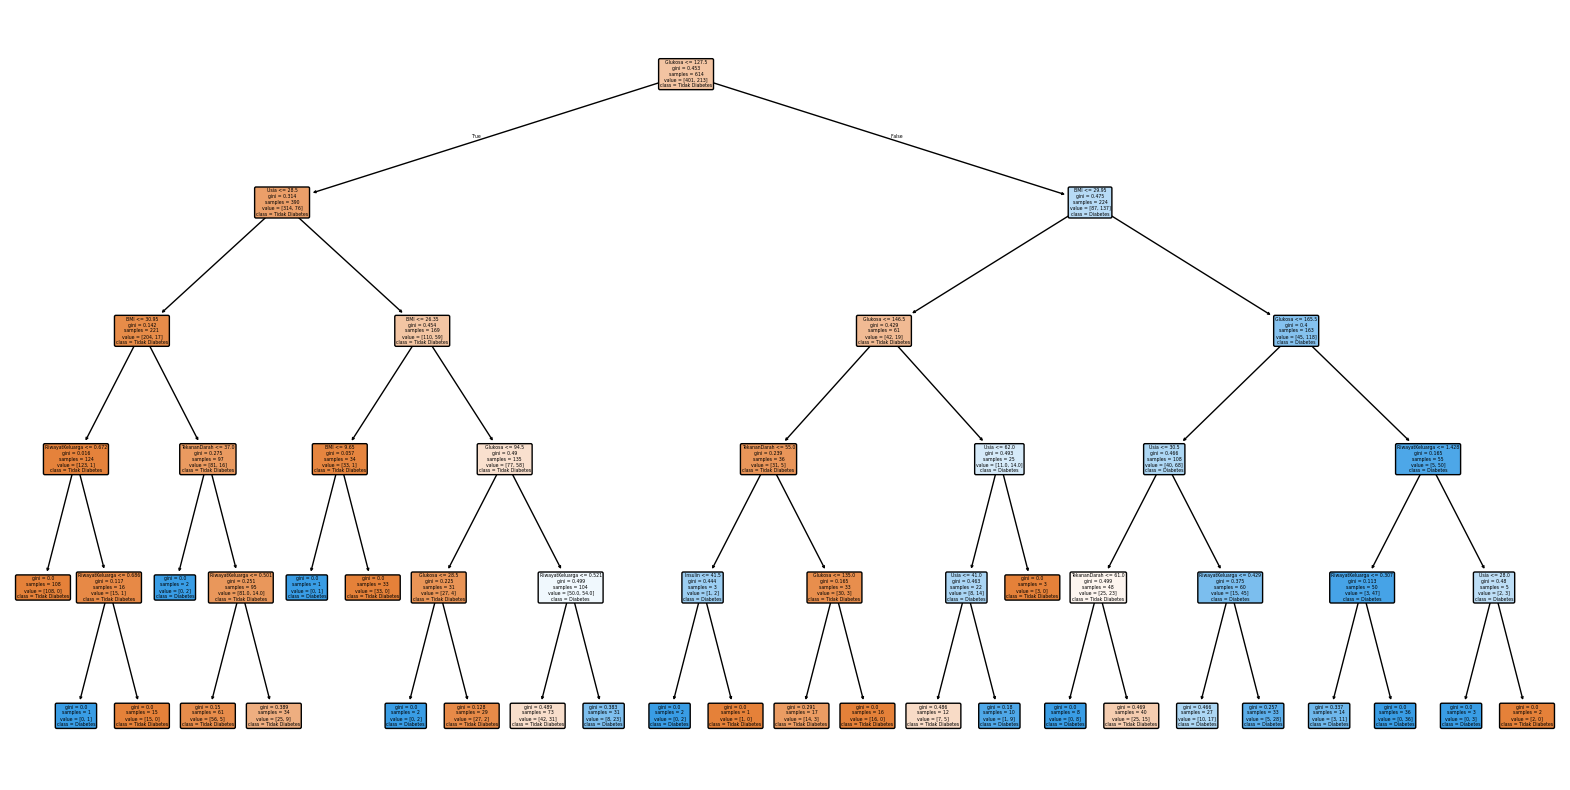

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(model_ClassifierDiabet,
          feature_names=nama_kolom[:-1],
          class_names=['Tidak Diabetes', 'Diabetes'],
          filled=True,
          rounded=True)
plt.show()